In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import  train_test_split


In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()
# df.info()
# df.describe()
# df.isnull().sum()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# HANDLING MISSING VALUES

In [4]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols]= num_imp.fit_transform(df[numerical_cols])
category_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols]= category_imp.fit_transform(df[categorical_cols])

In [6]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA - Exploratory Data Analysis 


Text(0.5, 1.0, 'Is loan approved or not?')

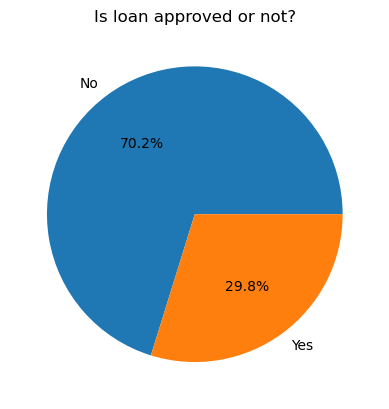

In [7]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No","Yes"], autopct = "%1.1f%%")
plt.title("Is loan approved or not?")

[Text(0, 0, '621'), Text(0, 0, '379')]

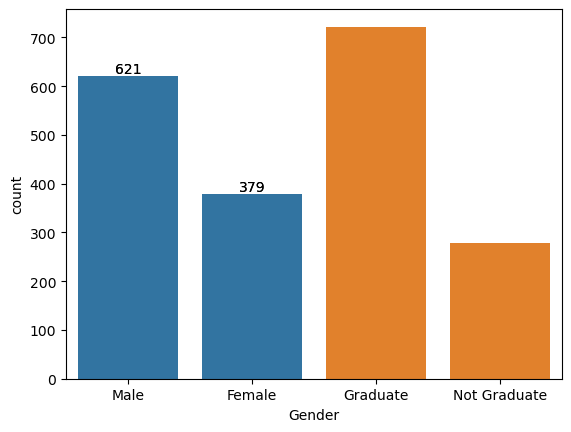

In [16]:
# analyze categories

genders_count = df["Gender"].value_counts()
ax = sns.barplot(genders_count)
ax.bar_label(ax.containers[0])

edu_count = df["Education_Level"].value_counts()
ax = sns.barplot(edu_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

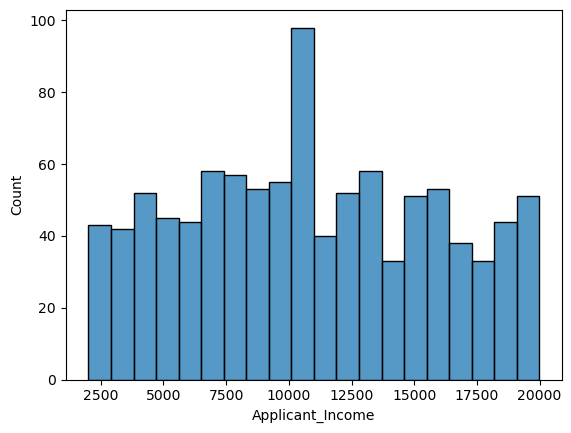

In [18]:
#analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

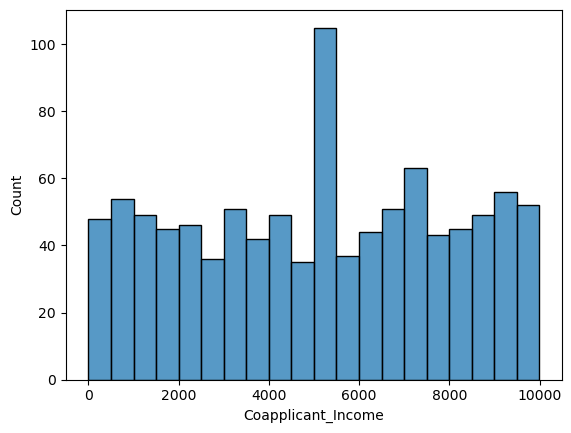

In [19]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

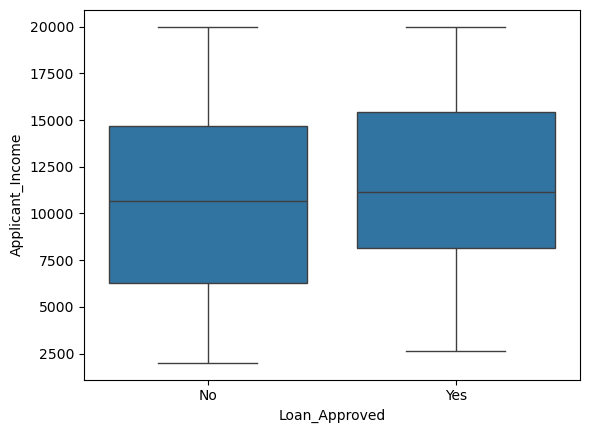

In [22]:
#Outliers - box plot
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
    
)

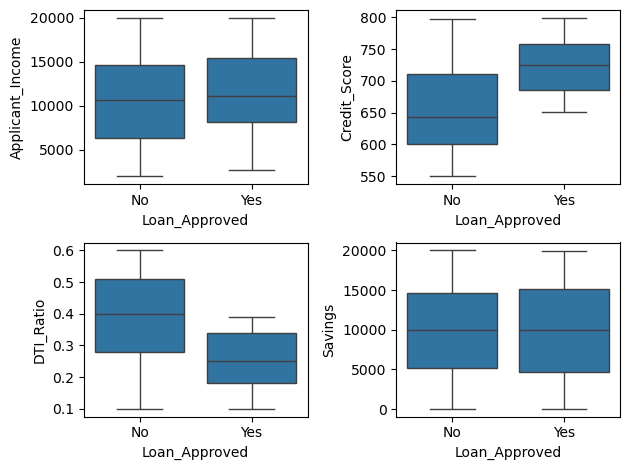

In [28]:
#finding outliers
fig , axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0], data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0], data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = df,x = "Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

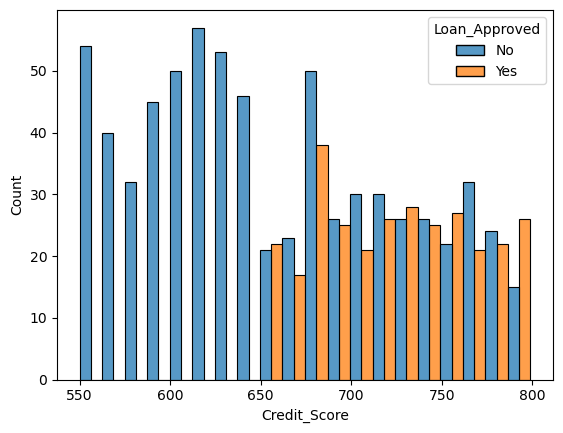

In [33]:
#Credit Score with Loan Appproved

sns.histplot(
    data = df,
    x="Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

In [35]:
#Remove Applicant_ID

df= df.drop("Applicant_ID",axis=1)

df.head()

# ENCODING